## Lecture 13

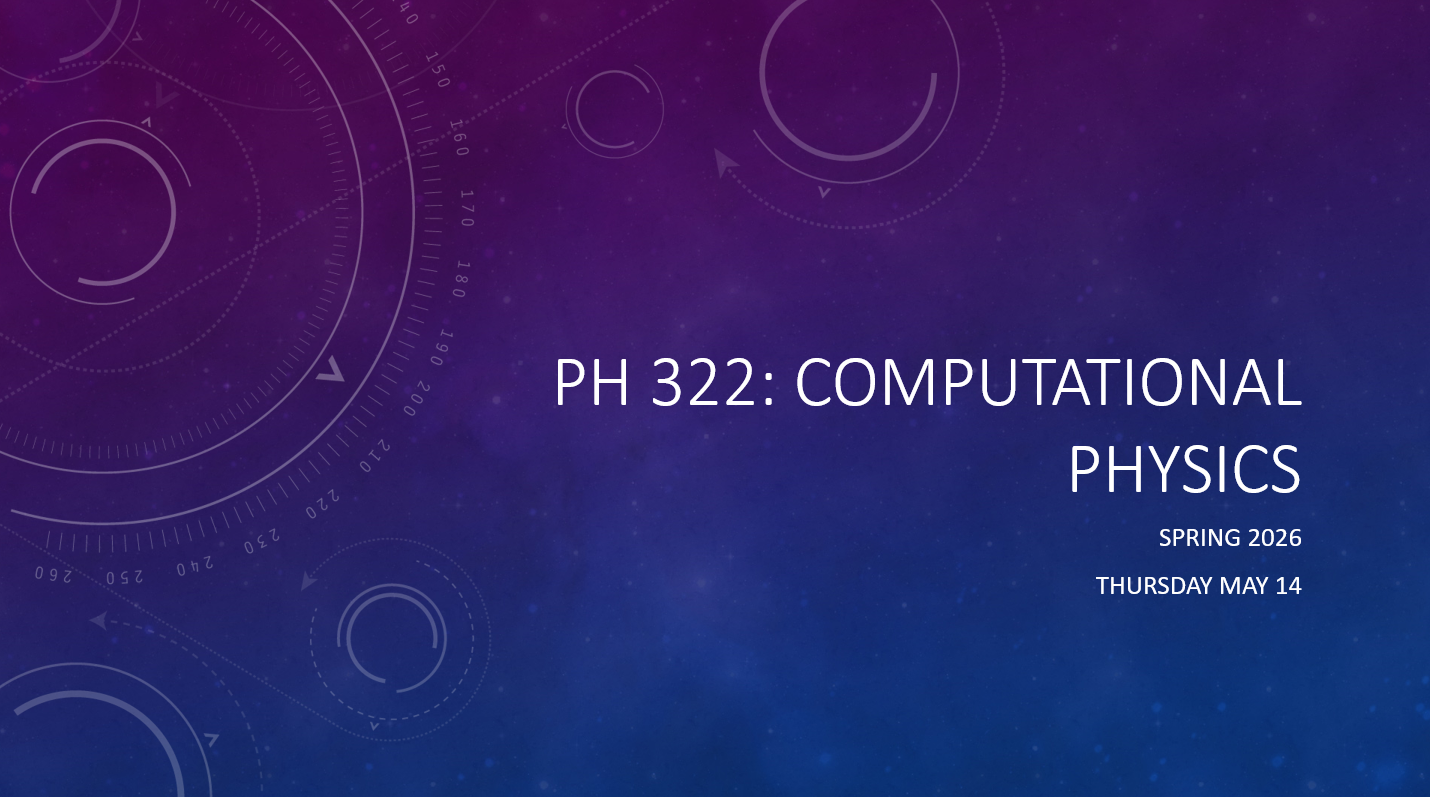

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture13.png"))

### Practice Exercise - Boundary value problem

Solve the differential equation:

$$
\frac{d^2y}{dt^2} = -g
$$

that governs the flight of a ball without air resistance, where $y$ is the height of the ball.  The boundary conditions are  y=0 0 m, at t=0, 10s. That is the ball must last land at t=10s. We are not given the initial velocity. 


### Pointers for coding the ODE boundary value problem

* Your program should include a function $f_v()$ that returns $y'(v_0, \text{t=10s})-y_t$, the difference between calculated height at t=10 seconds, and the boundary condition. 
* Within the function define the vector $\mathbf{f}(\mathbf{r},t)$ which returns the functions $f_y$, $f_v$, which are needed to solve the differential equation. 
* Set the initial velocity equal to the velocity that is passed to $f_v()$. 
* Bracket the correct initial velocity. You need to test whether the root lies inside the bracker. 
* If you want to plot the solution, you will also need to return $y$ at all time steps. This isn't necessary if you only want to know the correct initial velocity.

In [ ]:
# boundary value code
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import g

def rk4(f, t_start, t_end, N_steps, r0):

    h = (t_end - t_start)/N_steps
    time_steps = np.arange(t_start, t_end + h, h) # Renamed to time_steps for consistency

    r_approx = np.zeros((N_steps+1, 3)) # Correctly initialized as a 2D array of zeros
    r_approx[0]  = r0

    for i in range(1, time_steps.shape[0]):

        t = time_steps[i-1]
        r = r_approx[i-1]

        k_1 = h * f(r,t)
        k_2 = h * f(r + 1/2*k_1, t + 1/2 * h)
        k_3 = h * f(r + 1/2*k_2, t + 1/2 * h)
        k_4 = h * f(r + k_3, t + h)
        r_approx[i] = r + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

    return time_steps, r_approx

### Practice Exercise - Solve Laplace equation using the Jacobi method. 

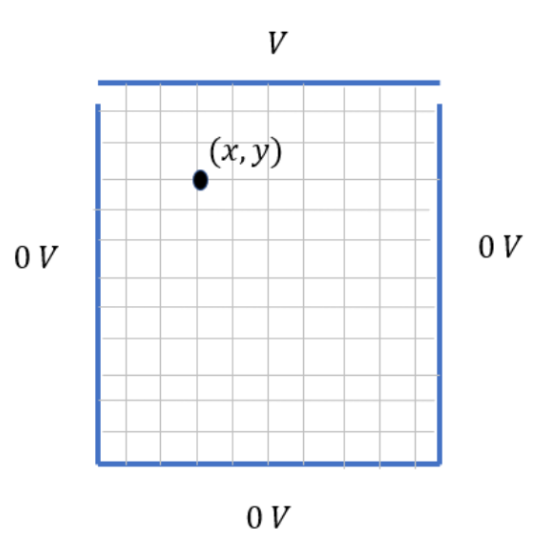

Solve the Laplace equation for the problem above. Set the potential at the top boundary to be 1 volt and zero along the other three walls. Calculate the potential over an $N\times N$ grid of size $N=100$ to an accuracy of $10^{-3}$ V.

Let's think about the pseudocode first.

* Create a user-defined function to calculate $\phi(x,y)$ using the equation above at each grid cell.
* Create an array of *NxN* which will store the solution $\phi$.
* Initialize $\phi$ at all grid points, including along the boundaries. 
* Use a ```while```-loop to test for convergence.
    * Create a copy of $\phi$ that will hold the estimated solutions from the previous iteration.
    * Loop over each **inner** grid point in the $\phi$ array using a nested ```for```-loop.
        *  Update your estimate of $\phi$ at grid point $(i,j$) using the previous estimate of $\phi$, now stored in your copy of $\phi$.
    * Check if $\phi$ has converged at each grid point (you can also check for this condition in your ```while``` statement). 
* Note, make sure you update only the inner grid points. The boundary values must remain constant. 

The equation for $\phi(x,y)$ above contains the grid spacing $a$. What will this be?

When you get your code working, make an image plot of your solution. Does it look reasonable? Count the number of iterations it takes for the solution to converge. Decrease the target error to $10^{-4}, 10^{-5}, \ldots$ and compare the number of iterations for each. 

In [ ]:
# Laplace equation code